# 01 — Data Exploration

Explore the ZeroWaste dataset: class distribution, image sizes, annotation density, and sample visualisations.

In [1]:
import json
import sys
from pathlib import Path
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Add project root to path so `src` imports work
sys.path.insert(0, str(Path("..").resolve()))

sns.set_theme(style="whitegrid", palette="muted")

DATA_DIR = Path("../data/zerowaste/splits_final_deblurred")

In [2]:
# Load annotations
with open(DATA_DIR / "train" / "labels.json") as f:
    train_coco = json.load(f)

print(f"Images: {len(train_coco['images'])}")
print(f"Annotations: {len(train_coco['annotations'])}")
print(f"Categories: {[c['name'] for c in train_coco['categories']]}")

Images: 3002
Annotations: 18002
Categories: ['rigid_plastic', 'cardboard', 'metal', 'soft_plastic']


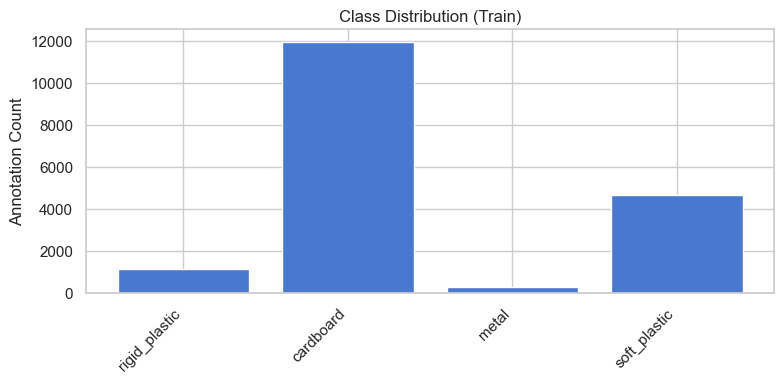

In [3]:
# Class distribution
cat_names = {c["id"]: c["name"] for c in train_coco["categories"]}
cat_counts = Counter(ann["category_id"] for ann in train_coco["annotations"])

fig, ax = plt.subplots(figsize=(8, 4))
names = [cat_names[k] for k in sorted(cat_counts.keys())]
counts = [cat_counts[k] for k in sorted(cat_counts.keys())]
ax.bar(names, counts)
ax.set_title("Class Distribution (Train)")
ax.set_ylabel("Annotation Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

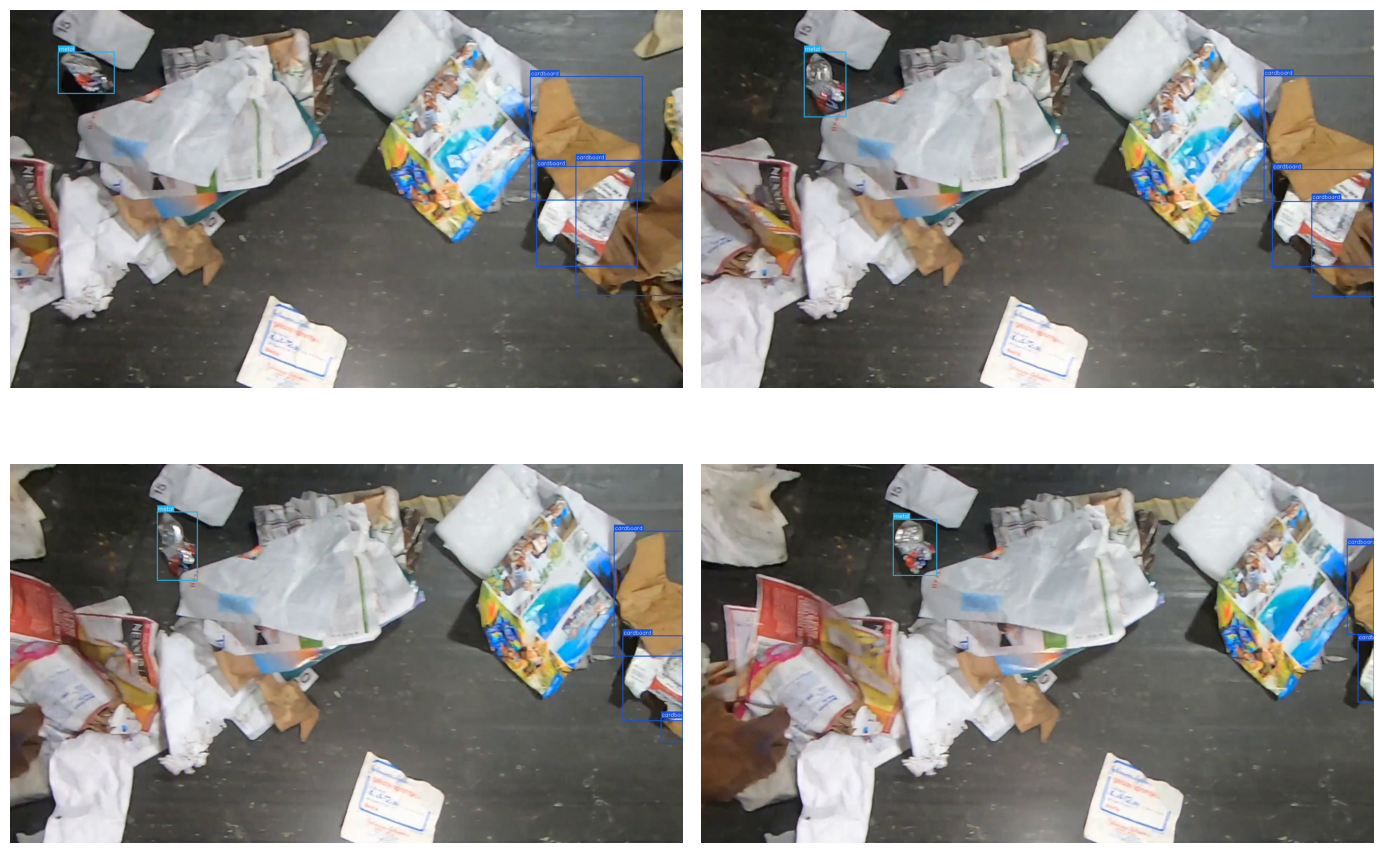

In [4]:
# Sample images with annotations
from src.evaluation.visualise import draw_detections

ann_by_img = {}
for ann in train_coco["annotations"]:
    ann_by_img.setdefault(ann["image_id"], []).append(ann)

sample_imgs = train_coco["images"][:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, img_info in zip(axes.flat, sample_imgs):
    img = cv2.imread(str(DATA_DIR / "train" / "data" / img_info["file_name"]))
    anns = ann_by_img.get(img_info["id"], [])
    boxes = [a["bbox"] for a in anns]
    labels = [cat_names[a["category_id"]] for a in anns]
    vis = draw_detections(img, boxes, labels)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.axis("off")

plt.tight_layout()
plt.show()